Install required libraries and restart kernel:

In [1]:
%pip install tensorflow==2.16.2
%pip install matplotlib==3.9.2
%pip install numpy==1.26.4
%pip install scipy==1.14.1
%pip install scikit-learn==1.5.2
%pip install tqdm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Import libraries:

In [2]:
# Standard library imports
import os
import zipfile
import urllib.request
import logging
from collections import Counter
from datetime import datetime
from typing import Optional
from pathlib import Path

# Third-party imports
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# TensorFlow imports
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.applications import VGG16, MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, 
    Flatten, 
    Dropout, 
    BatchNormalization, 
    GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.mixed_precision import set_global_policy

In [3]:
# Logger setup
_LOGGER = logging.getLogger(__name__)


def setup_logging(debug: bool = True) -> None:
    """Configure logging with proper timestamp formatting."""
    level = logging.DEBUG if debug else logging.INFO
    logging.basicConfig(
        level=level,
        format="%(asctime)s %(levelname)s: %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
    )
    _LOGGER.setLevel(level)


# Initialize logging 
setup_logging(debug = True)

Download and extract dataset

In [4]:
def download_dataset(url: str, output_file: str) -> Path:
    """
    Download a dataset from a URL with tqdm progress bar and logging.

    Creates parent directories if needed, shows real-time download progress
    via tqdm (bytes, unit scaling, rate), and logs start/completion with final size.

    Args:
        url (str): Remote URL to download (e.g., ZIP dataset).
        output_file (str): Local path to save file (str or Path-like).

    Returns:
        Path: Path to the downloaded file.

    Raises:
        urllib.error.URLError: If download fails (network, invalid URL).
        OSError: If file write fails (permissions, disk space).

    Example:
        >>> download_dataset("https://example.com/data.zip", "data/fruits.zip")
        PosixPath('data/fruits.zip')
    """
    output_file = Path(output_file)
    _LOGGER.info(f"📥 Downloading {url}...")
    
    output_file.parent.mkdir(parents=True, exist_ok=True)
    
    def tqdm_hook(t):
        last_b = [0]
        def inner(b=1, bs=1, tsize=None):
            downloaded = b * bs
            t.update(downloaded - last_b[0])
            last_b[0] = downloaded
        return inner
    
    urllib.request.urlretrieve(url, str(output_file), reporthook=tqdm_hook(tqdm(unit='B', unit_scale=True)))
    
    file_size = os.path.getsize(output_file) / (1024**2)
    _LOGGER.info(f"✅ Download COMPLETE ({file_size:.1f} MB)")
    return output_file



def extract_zip_in_chunks(
    zip_path: str, 
    extract_to: str, 
    batch_size: int = 1000,
    overwrite: bool = False
) -> None:
    """
    Extract large ZIP file in memory-efficient batches with progress logging.

    Processes files in batches to avoid loading the entire ZIP index into memory.
    Skips directories and existing files (unless overwrite=True). Logs batch progress.

    Args:
        zip_path (str): Path to input ZIP file (must exist).
        extract_to (str): Root directory to extract contents (created if needed).
        batch_size (int): Number of files to extract per batch (default: 1000).
        overwrite (bool): Extract even if files exist (default: False).

    Returns:
        None

    Raises:
        FileNotFoundError: If zip_path does not exist.
        zipfile.BadZipFile: If ZIP is corrupted/invalid.
        PermissionError: If cannot write to extract_to.

    Example:
        >>> extract_zip_in_chunks("data/fruits.zip", "data/extracted", batch_size=500)
        Extracts fruits-360 dataset in 500-file chunks.
    """
    zip_path = Path(zip_path)
    extract_to = Path(extract_to)
    
    if not zip_path.exists():
        raise FileNotFoundError(f"❌ ZIP not found: {zip_path}")
    
    _LOGGER.info(f"📦 Extracting {zip_path} → {extract_to} (batch={batch_size})")
    extract_to.mkdir(parents=True, exist_ok=True)
    
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        file_list = zip_ref.namelist()
        total_files = len(file_list)
        _LOGGER.debug(f"Found {total_files} files")
        
        for i in range(0, total_files, batch_size):
            batch = file_list[i:i + batch_size]
            extracted_count = 0
            
            for file_path in batch:
                if file_path.endswith('/'):
                    continue
                
                target_path = extract_to / file_path
                if overwrite or not target_path.exists():
                    target_path.parent.mkdir(parents=True, exist_ok=True)
                    zip_ref.extract(file_path, extract_to)
                    extracted_count += 1
            
            progress = (i + batch_size) / total_files * 100
            _LOGGER.info(
                f"📊 Batch {i//batch_size + 1}: "
                f"{min(i + batch_size, total_files)}/{total_files} "
                f"({progress:.1f}%)"
            )
    
    _LOGGER.info(f"✅ Extraction done: {extract_to}")


def prepare_dataset(
    dataset_url: str,
    zip_path: str,
    extract_path: str,
    fallback_urls: list[str] | None = None,
    force_download: bool = False,
    force_extract: bool = False,
    batch_size: int = 1000,
    auto_cleanup: bool = False,
) -> tuple[Path, Path]:
    """
    Download and extract dataset with fallback URLs, retries, and cleanup.

    Tries primary URL + fallbacks until success. Downloads if ZIP missing/forced,
    extracts in chunks if dir missing/forced. Cleans up ZIP post-extraction if enabled.
    Handles failures gracefully, raises only if all URLs fail.

    Args:
        dataset_url (str): Primary URL for ZIP download.
        zip_path (str): Local path to save ZIP (created if missing).
        extract_path (str): Dir to extract contents (created if missing).
        fallback_urls (list[str] | None): Backup URLs if primary fails (default: None).
        force_download (bool): Re-download even if ZIP exists (default: False).
        force_extract (bool): Re-extract even if dir exists (default: False).
        batch_size (int): Files per extract batch (default: 1000).
        auto_cleanup (bool): Delete ZIP after successful extraction (default: False).

    Returns:
        tuple[Path, Path]: (zip_path, extract_path) - paths to ZIP and extracted data.

    Raises:
        RuntimeError: If all URLs fail to download.
        urllib.error.URLError: Download failures (propagated from download_dataset).
        zipfile.BadZipFile: Corrupted ZIP (from extract_zip_in_chunks).

    Example:
        >>> zip_p, ext_p = prepare_dataset(
        ...     "https://example.com/fruits.zip",
        ...     "data/fruits.zip",
        ...     "data/fruits-extracted",
        ...     fallback_urls=["https://backup.com/fruits.zip"],
        ...     auto_cleanup=True
        ... )
        >>> ext_p / "Training"  # Contains extracted images
        PosixPath('data/fruits-extracted/Training')
    """

    zip_path = Path(zip_path)
    extract_path = Path(extract_path)
    
    urls_to_try = [dataset_url]
    if fallback_urls:
        urls_to_try.extend([u for u in fallback_urls if u != dataset_url])
    
    for url in urls_to_try:
        try:
            _LOGGER.info(f"🔄 Attempting: {url}")
            
            if force_download or not zip_path.exists():
                zip_path = download_dataset(url, zip_path)
            
            if force_extract or not extract_path.exists():
                extract_zip_in_chunks(zip_path, extract_path, batch_size)
            
            _LOGGER.info(f"✅ SUCCESS: {url}")
            break
            
        except Exception as e:
            _LOGGER.warning(f"❌ Failed {url}: {str(e)[:100]}...")
            continue
    else:
        raise RuntimeError(f"All {len(urls_to_try)} URLs failed!")
    
    if auto_cleanup and zip_path.exists() and extract_path.exists():
        zip_path.unlink()
        _LOGGER.info("🧹 ZIP cleaned up")
    
    _LOGGER.info(f"🎉 Dataset ready → {zip_path} | {extract_path}")
    return zip_path, extract_path


In [5]:
# Dataset configuration
IBM_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/4yIRGlIpNfKEGJYMhZV52g/fruits-360-original-size.zip"
GITHUB_URL = "https://github.com/fruits-360/fruits-360-original-size/archive/refs/heads/main.zip"
LOCAL_ZIP = "fruits-360-original-size.zip"
EXTRACT_DIR = "fruits-360-original-size"

# Download and extract dataset
zip_file, data_dir = prepare_dataset(
    dataset_url=IBM_URL,
    zip_path=LOCAL_ZIP,
    extract_path=EXTRACT_DIR,
    fallback_urls=[GITHUB_URL]
)


2026-03-08 17:16:39 INFO: 🔄 Attempting: https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/4yIRGlIpNfKEGJYMhZV52g/fruits-360-original-size.zip
2026-03-08 17:16:39 INFO: ✅ SUCCESS: https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/4yIRGlIpNfKEGJYMhZV52g/fruits-360-original-size.zip
2026-03-08 17:16:39 INFO: 🎉 Dataset ready → fruits-360-original-size.zip | fruits-360-original-size


In [6]:
# Directory structure 

# Ensure that your data set is organized as follows: 


# dataset/
# ├── train/
# │   ├── Class1/
# │   ├── Class2/
# │   ├── Class3/
# │   └── (other classes...)
# ├── val/
# │   ├── Class1/
# │   ├── Class2/
# │   ├── Class3/
# │   └── (other classes...)
# └── test/
#     ├── Class1/
#     ├── Class2/
#     ├── Class3/
#     └── (other classes...)


# Each subdirectory under train and val should contain images of the respective fruit category. 

Set up data generators for training, validation, and testing with augmentation

In [7]:
# Set dataset paths
train_dir = 'fruits-360-original-size/fruits-360-original-size/Training'
val_dir = 'fruits-360-original-size/fruits-360-original-size/Validation'
test_dir = 'fruits-360-original-size/fruits-360-original-size/Test'

# train_dir = 'fruits-360-original-size/fruits-360-original-size-main/Training'
# val_dir = 'fruits-360-original-size/fruits-360-original-size-main/Validation'
# test_dir = 'fruits-360-original-size/fruits-360-original-size-main/Test'



batch_size = 32

# Image data generators
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
)

val_datagen = ImageDataGenerator(rescale=1.0/255.0)
test_datagen = ImageDataGenerator(rescale=1.0/255.0)

# Load images from directories
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(128, 128),
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128, 128),
    batch_size=batch_size,
    class_mode='categorical'
)


Found 6231 images belonging to 24 classes.
Found 3114 images belonging to 24 classes.
Found 3110 images belonging to 24 classes.


Define the VGG16-based model architecture with custom layers

In [8]:
# Load VGG16 with pre-trained weights
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

# Build the model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(train_generator.num_classes, activation='softmax')
])

# Compile phase 1 (frozen base)
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stopping = EarlyStopping(patience=5, restore_best_weights=True)
lr_scheduler  = ReduceLROnPlateau(factor=0.2, patience=3, min_lr=1e-6, verbose=1)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,117,912 (57.67 MB)

 Trainable params: 401,688 (1.53 MB)

 Non-trainable params: 14,716,224 (56.14 MB)

Train model

In [10]:

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator, 
    callbacks=[lr_scheduler, early_stopping]
)

Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 149s 756ms/step - accuracy: 0.6039 - loss: 1.3155 - val_accuracy: 0.6557 - val_loss: 1.2890 - learning_rate: 0.0010
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 149s 766ms/step - accuracy: 0.8204 - loss: 0.5322 - val_accuracy: 0.9387 - val_loss: 0.2817 - learning_rate: 0.0010
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 147s 752ms/step - accuracy: 0.8745 - loss: 0.3718 - val_accuracy: 0.9024 - val_loss: 0.2719 - learning_rate: 0.0010
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 150s 770ms/step - accuracy: 0.8920 - loss: 0.3145 - val_accuracy: 0.9441 - val_loss: 0.1585 - learning_rate: 0.0010
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 151s 775ms/step - accuracy: 0.9092 - loss: 0.2646 - val_accuracy: 0.9573 - val_loss: 0.1142 - learning_rate: 0.0010
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 148s 761ms/step - accuracy: 0.9173 - loss: 0.2426 - val_accuracy: 0.9374 - val_loss: 0.1490 - learning_rate: 0.0010
Epoch 7/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 152s 782ms/step - accura

Fine-tune model

In [11]:
# Check the number of layers in the base model
num_layers = len(base_model.layers)
_LOGGER.info(f"The base model has {num_layers} layers.")

# Print layers for insight (VGG16 base ~19 layers)
_LOGGER.info("Layers:", [l.name for l in base_model.layers[-10:]])

# Fine-tune: unfreeze top 8 layers
for layer in base_model.layers[-8:]:
    layer.trainable = True

# Freeze BatchNorm layers to speed up fine-tuning
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Re-compile the model with low LR
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)



2026-03-08 17:41:32 INFO: The base model has 19 layers.
--- Logging error ---
Traceback (most recent call last):
  File "C:\Python312\Lib\logging\__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "C:\Python312\Lib\logging\__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "C:\Python312\Lib\logging\__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "C:\Python312\Lib\logging\__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "f:\OneDrive\projekty_na_github\fruit_classification\venv\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "f:\OneDrive\pro

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,117,912 (57.67 MB)

 Trainable params: 13,380,888 (51.04 MB)

 Non-trainable params: 1,737,024 (6.63 MB)

In [14]:
# Continue training with fewer steps per epoch
history_fine = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    callbacks=[lr_scheduler, early_stopping]
)

Epoch 1/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 236s 1s/step - accuracy: 0.9652 - loss: 0.1070 - val_accuracy: 0.9994 - val_loss: 0.0104 - learning_rate: 1.0000e-05
Epoch 2/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 237s 1s/step - accuracy: 0.9775 - loss: 0.0713 - val_accuracy: 0.9984 - val_loss: 0.0101 - learning_rate: 1.0000e-05
Epoch 3/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 237s 1s/step - accuracy: 0.9862 - loss: 0.0492 - val_accuracy: 0.9865 - val_loss: 0.0468 - learning_rate: 1.0000e-05
Epoch 4/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 233s 1s/step - accuracy: 0.9900 - loss: 0.0379 - val_accuracy: 0.9978 - val_loss: 0.0117 - learning_rate: 1.0000e-05
Epoch 5/5
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 933ms/step - accuracy: 0.9926 - loss: 0.0314
Epoch 5: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
195/195 ━━━━━━━━━━━━━━━━━━━━ 229s 1s/step - accuracy: 0.9918 - loss: 0.0322 - val_accuracy: 0.9839 - val_loss: 0.0353 - learning_rate: 1.0000e-05


Evaluate the model on the test set

In [15]:
# Evaluate on the test set
test_loss, test_accuracy = model.evaluate(test_generator, steps=50)
_LOGGER.info(f"Test Accuracy: {test_accuracy:.2f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 25s 489ms/step - accuracy: 0.9994 - loss: 0.0078


2026-03-08 18:02:54 INFO: Test Accuracy: 1.00


Plots the training and validation accuracy and training and validation loss

2026-03-08 18:02:54 DEBUG: Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-03-08 18:02:54 DEBUG: Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-03-08 18:02:54 DEBUG: findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2026-03-08 18:02:54 DEBUG: findfont: score(FontEntry(fname='f:\\OneDrive\\projekty_na_github\\fruit_classification\\venv\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSans-Oblique.ttf', name='DejaVu Sans', style='oblique', variant='normal', weight=400, stretch='normal', size='scalable')) = 1.05
2026-03-08 18:02:54 DEBUG: findfont: score(FontEntry(fname='f:\\OneDrive\\projekty_na_github\\fruit_classification\\venv\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXSizFourSymReg.ttf', name='STIXSizeFourSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-03-08 18:02:54 DEBUG: findfont: score(Font

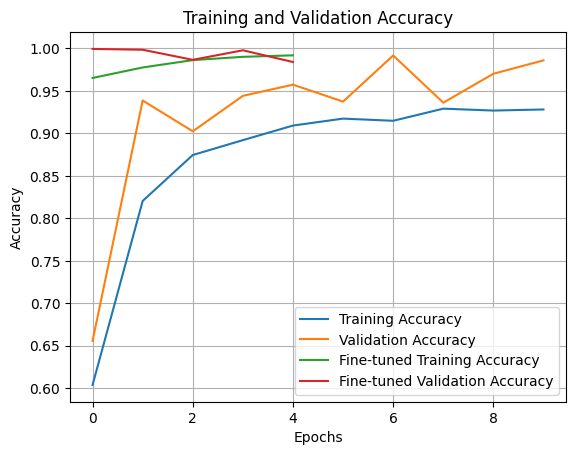

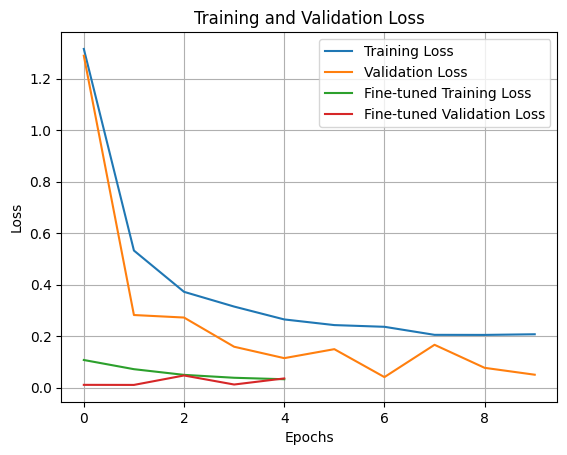

In [16]:
# Plot accuracy and loss curves
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(history_fine.history['accuracy'], label='Fine-tuned Training Accuracy')
plt.plot(history_fine.history['val_accuracy'], label='Fine-tuned Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.grid(True)
plt.show()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.plot(history_fine.history['loss'], label='Fine-tuned Training Loss')
plt.plot(history_fine.history['val_loss'], label='Fine-tuned Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.grid(True)
plt.show()